In [1]:
import sys
sys.path.append('../../../../src')
sys.path.append('../../../..')

import os
from dataclasses import replace

from PIL import ImageFont
import matplotlib.pyplot as plt
import numpy as np
from palette.symbol2value import PALETTES, stream_width_aligned_permutations
from converters.img_converter import ImgConverter
from converters.line_heuristics.line_converter import LineConverter
from converters.tile.nearest import Tile2SymbNearest

from tests.experimental.test_loop import Params, test_loop

FONT_PATH = "../../../../fonts/OpenSans-Regular.ttf"
FONT_SIZE = 10
FONT = ImageFont.truetype(FONT_PATH, FONT_SIZE)
SYMBOLS = list(stream_width_aligned_permutations(PALETTES['asciis'], FONT, skip_chance=0.3))
MAX_COLS = 10
MAX_LINES = 10
NUM_IMGS = 100
IMG_SET_PATH = "../../../../imgs/BSDS500-ds"
IMG_PATHS = [os.path.join(IMG_SET_PATH, img_name)
             for img_name in os.listdir(IMG_SET_PATH)[:NUM_IMGS]]


def make_converter(params: Params):
    converter_args = params.converter_args.copy()
    val_wh = (3, 3)
    if 'val_wh' in converter_args:
        val_wh = converter_args['val_wh']
        del converter_args['val_wh']

    converter = LineConverter(tile_converter=Tile2SymbNearest(symbols=SYMBOLS,
                                                              font=FONT,
                                                              val_wh=val_wh,
                                                              **converter_args))

    return ImgConverter(converter, FONT)

d:\CS Projects\python-playground\python-ascii-art\tests\experimental\grayscale\non_monospaced\../../../../src\converters\tile\nearest.py:40: UserWarning: It is recommended to use mode = grid-constant instead of constant when grid_mode is True.
  tile = zoom(tile, zoom_factors, order=0, grid_mode=True)


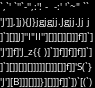

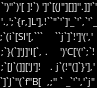

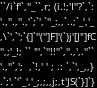

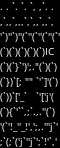

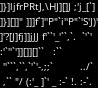

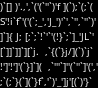

In [2]:
from PIL import Image
from image.processing import preprocess_img
from rendering.image import render_symbols_img

default_params = Params(max_cols=MAX_COLS,
                        max_lines=MAX_LINES,
                        font_path=FONT_PATH,
                        font_size=FONT_SIZE)

converter = make_converter(default_params)

line_height = int(default_params.font_size * 1.333)
col_width = line_height

results = []
for img_path in IMG_PATHS[:6]:
    img = Image.open(img_path).convert("L")
    img = preprocess_img(img, contrast=1.7)
    res_arr = converter.img2symbols(img,
                                    max_cols=MAX_COLS,
                                    max_lines=MAX_LINES,
                                    gens_per_step=default_params.gens_per_step)
    display(render_symbols_img(res_arr, FONT))

Min: 0.0331 | Max: 0.1920 | Mean: 0.1030 | Std: 0.0344
Min: 0.0761 | Max: 0.2568 | Mean: 0.1536 | Std: 0.0345
Min: 0.0906 | Max: 0.3066 | Mean: 0.1690 | Std: 0.0380
Min: 0.1009 | Max: 0.3310 | Mean: 0.1753 | Std: 0.0411
Min: 0.1035 | Max: 0.3467 | Mean: 0.1757 | Std: 0.0433


C:\Users\wojte\AppData\Local\Temp\ipykernel_21984\1448939046.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(similarity_scores,


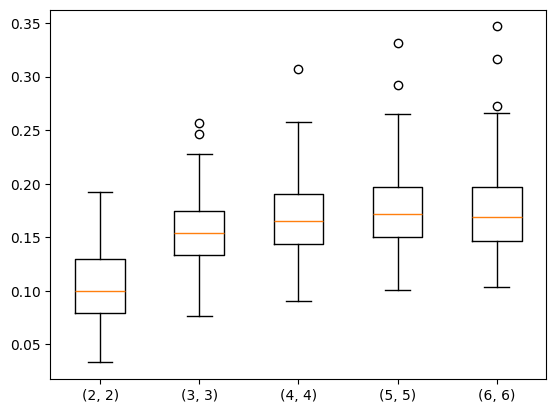

In [3]:
# val_wh

params_space = [
    (w, w) for w in range(2, 7, 1)
]

params_space = list(
    map(lambda val_wh: replace(default_params, converter_args={'val_wh': val_wh}),
        params_space))

similarity_scores = test_loop(IMG_PATHS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=[param.converter_args['val_wh'] for param in params_space])
plt.show()

Min: 0.0271 | Max: 0.1677 | Mean: 0.1129 | Std: 0.0266
Min: 0.0633 | Max: 0.2323 | Mean: 0.1447 | Std: 0.0332
Min: 0.0902 | Max: 0.3044 | Mean: 0.1713 | Std: 0.0404
Min: 0.0968 | Max: 0.3250 | Mean: 0.1895 | Std: 0.0456
Min: 0.1026 | Max: 0.3804 | Mean: 0.2008 | Std: 0.0466


C:\Users\wojte\AppData\Local\Temp\ipykernel_21984\2305421242.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(similarity_scores,


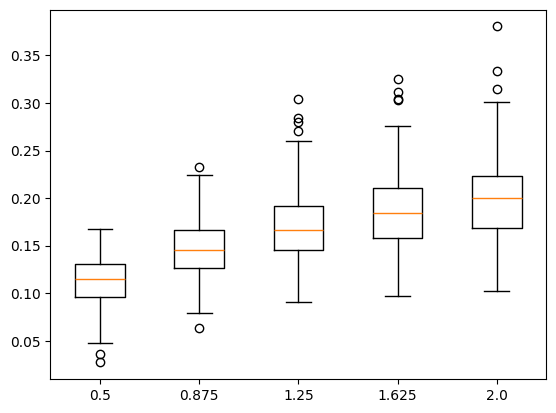

In [4]:
# contrast

params_space = [
    {'contrast': c} for c in np.linspace(0.5, 2.0, 5, endpoint=True)
]

params_space = list(
    map(lambda preprocess_args: replace(default_params, preprocess_args=preprocess_args),
        params_space))

similarity_scores = test_loop(IMG_PATHS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=[param.preprocess_args['contrast'] for param in params_space])
plt.show()

Min: 0.0617 | Max: 0.2423 | Mean: 0.1531 | Std: 0.0339
Min: 0.0302 | Max: 0.1950 | Mean: 0.1042 | Std: 0.0303
Min: 0.0282 | Max: 0.5746 | Mean: 0.1618 | Std: 0.0959


C:\Users\wojte\AppData\Local\Temp\ipykernel_21984\1162874657.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(similarity_scores,


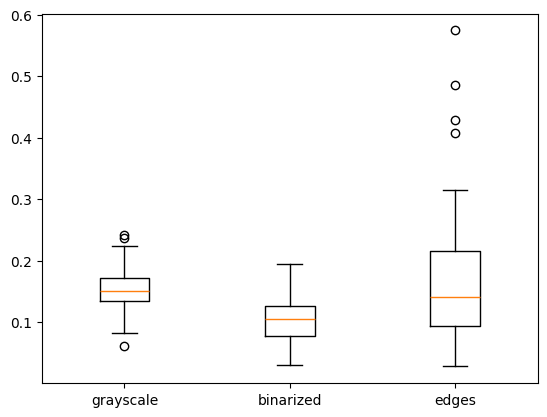

In [5]:
params_space = [default_params]
similarity_scores = test_loop(IMG_PATHS, make_converter, params_space)

IMG_BIN_SET_PATH = "../../../../imgs/BSDS500-ds-bin"
IMG_BIN_PATHS = [os.path.join(IMG_BIN_SET_PATH, img_name)
             for img_name in os.listdir(IMG_BIN_SET_PATH)[:NUM_IMGS]]

similarity_scores += test_loop(IMG_BIN_PATHS, make_converter, params_space)

IMG_EDGE_SET_PATH = "../../../../imgs/BSDS500-ds-edge-bin"
IMG_EDGE_PATHS = [os.path.join(IMG_EDGE_SET_PATH, img_name)
             for img_name in os.listdir(IMG_EDGE_SET_PATH)[:NUM_IMGS]]

similarity_scores += test_loop(IMG_EDGE_PATHS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=['grayscale', 'binarized', 'edges'])
plt.show()